In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from safety_formation.control_law.cbf import CentralizedCBF
from safety_formation.formation import Agent,Topology

## Static Obstacle Avoidance

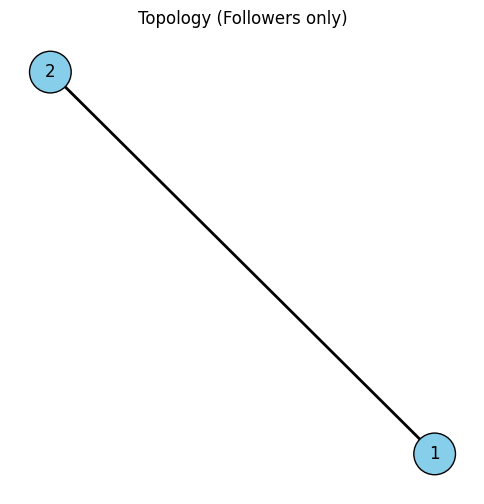

In [4]:
gamma = 0.8
d_min = 0.5

# State format: [x, y, vx, vy]
x_agent0  = [0.0,  0.0,  0.0, 0.0]
x_obs0    = [5.0, -0.05, 0.0, 0.0]
x_target  = np.array([10.0, 0.0, 0.0, 0.0], dtype=float)

alpha_agent = 6.0
alpha_obs   = 0.0   # static obstacle

# --- Create agents using your Agent class ---
# f_target is not used in this experiment, so set it to zeros
agent = Agent(agent_id=1, x0=x_agent0, f_target=[0, 0, 0, 0], alpha=alpha_agent)
obs   = Agent(agent_id=2, x0=x_obs0,   f_target=[0, 0, 0, 0], alpha=alpha_obs)

all_agents = [agent, obs]

# Save initial states if you want history from t=0
for ag in all_agents:
    ag.save_history()

# --- Create topology ---
# Agent and obstacle are connected so CBF checks safety constraint between them
adj = np.array([
    [0, 1],
    [1, 0]
], dtype=float)

topology = Topology(num_agents=2, adjacency_matrix=adj)
topology.plot()

# --- Create CBF filter ---
cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- History buffers ---
robot_history = []
u_hat_history = []
u_safe_history = []
h_history = []
dist_history = []

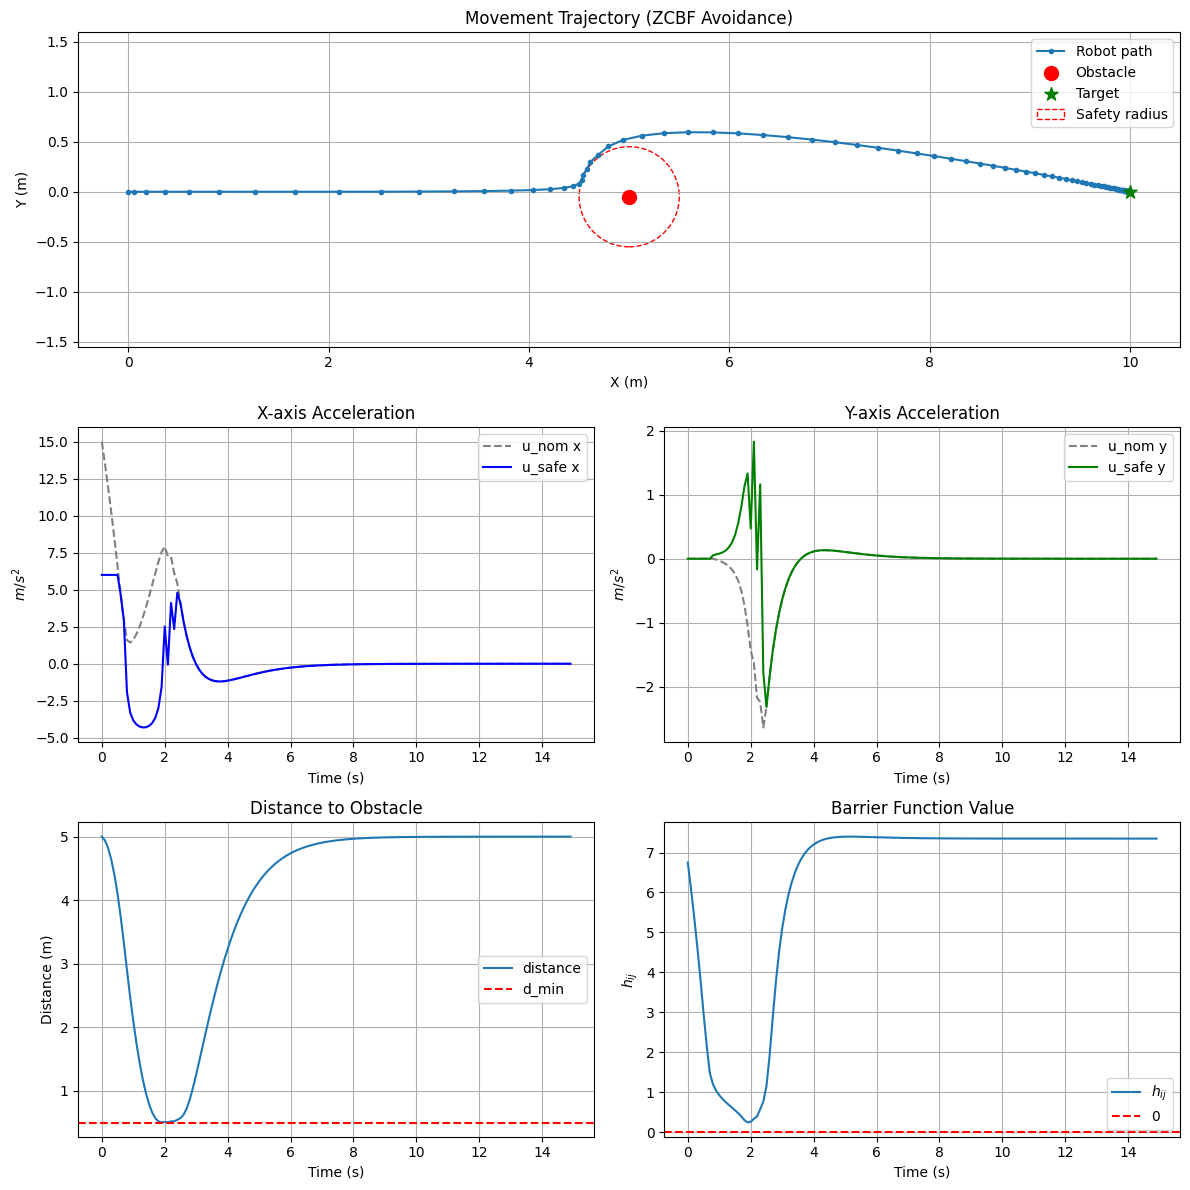

In [5]:
T = 15.0
dt = 0.1
steps = int(T / dt)

for k in range(steps):
    # Current robot state
    x_agent = agent.state.flatten()

    # 1) Nominal controller (PD-like tracking to target)
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]

    # 2) Build centralized nominal input for all "agents"
    # obstacle nominal input = 0 because obstacle is static
    u_nom_all = np.array([
        u_hat,
        [0.0, 0.0]
    ], dtype=float)

    # 3) Run CBF-QP filter
    u_safe_all = cbf_filter.compute_safe_control(all_agents, topology, u_nom_all)

    # Safe control for moving robot
    u_apply = u_safe_all[0]

    # 4) Update physics
    # robot moves with safe input
    agent.update_physics(u_apply, dt)

    # obstacle stays fixed
    obs.update_physics([0.0, 0.0], dt)

    # 5) Store histories
    robot_history.append(agent.state.flatten())
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # Optional diagnostics: current distance and barrier-like quantity
    dp = agent.pos - obs.pos
    dv = agent.vel - obs.vel
    dist = max(np.linalg.norm(dp), 1e-6)
    dist_history.append(dist)

    # Avoid sqrt of negative when dist < d_min
    margin = max(dist - d_min, 1e-6)
    term_safe_v = np.sqrt(2 * (agent.alpha + obs.alpha) * margin)
    h_val = term_safe_v + float((dp.T @ dv).item()) / dist
    
    h_history.append(h_val)

# --- Convert histories to arrays ---
robot_history = np.array(robot_history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
dist_history = np.array(dist_history)
h_history = np.array(h_history)
time = np.arange(steps) * dt

# --- Plotting ---
fig = plt.figure(figsize=(12, 12))

# 1. Trajectory
ax1 = plt.subplot(3, 1, 1)
ax1.plot(robot_history[:, 0], robot_history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter([x_obs0[0]], [x_obs0[1]], color='red', s=100, label='Obstacle', zorder=5)
ax1.scatter([x_target[0]], [x_target[1]], color='green', s=100, marker='*', label='Target', zorder=5)
circle = plt.Circle((x_obs0[0], x_obs0[1]), d_min, color='red', fill=False, linestyle='--', label='Safety radius')
ax1.add_patch(circle)
ax1.set_title("Movement Trajectory (ZCBF Avoidance)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.axis("equal")
ax1.grid(True)
ax1.legend()

# 2. Control signals
ax2 = plt.subplot(3, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom x')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe x')
ax2.set_title("X-axis Acceleration")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"$m/s^2$")
ax2.grid(True)
ax2.legend()

ax3 = plt.subplot(3, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe y')
ax3.set_title("Y-axis Acceleration")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel(r"$m/s^2$")
ax3.grid(True)
ax3.legend()

# 3. Distance to obstacle
ax4 = plt.subplot(3, 2, 5)
ax4.plot(time, dist_history, label='distance')
ax4.axhline(d_min, linestyle='--', color='red', label='d_min')
ax4.set_title("Distance to Obstacle")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Distance (m)")
ax4.grid(True)
ax4.legend()

# 4. h_ij evolution
ax5 = plt.subplot(3, 2, 6)
ax5.plot(time, h_history, label=r'$h_{ij}$')
ax5.axhline(0.0, linestyle='--', color='red', label='0')
ax5.set_title("Barrier Function Value")
ax5.set_xlabel("Time (s)")
ax5.set_ylabel(r"$h_{ij}$")
ax5.grid(True)
ax5.legend()

plt.tight_layout()
plt.show()

## Collision Avoidance for MAS

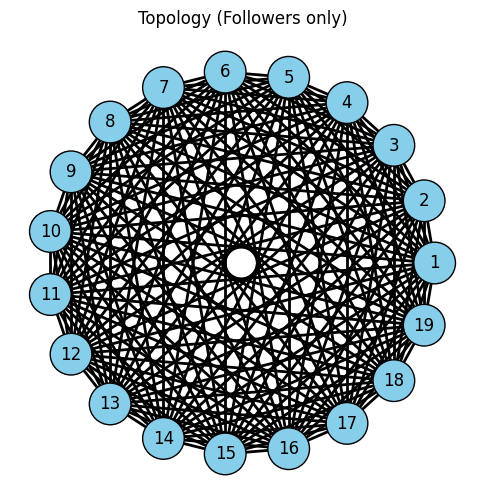

In [6]:
# --- Simulation Configuration ---
N = 19
R_circle = 150
dt = 0.1
T_max = 25.0
steps = int(T_max / dt)

gamma = 0.0011
d_min = 18.0
k1, k2 = 1.35 , 2.8

alpha_val = 10.0
beta_val = 20.0

# --- Create agents using your Agent class ---
agents_list = []

for i in range(N):
    angle = 2 * np.pi * i / N

    # Initial state: [x, y, vx, vy]
    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    # Opposite-side target
    target_pos = -np.array(x0[0:2]) - 10

    # f_target is not used in this experiment
    ag = Agent(
        agent_id=i,
        x0=x0,
        f_target=[0.0, 0.0, 0.0, 0.0],
        alpha=alpha_val,
        beta=beta_val
    )

    # attach target for this experiment
    ag.target = target_pos.reshape(2,)
    agents_list.append(ag)

# --- Fully connected topology ---
adj_matrix = np.ones((N, N)) - np.eye(N)
topology = Topology(num_agents=N, adjacency_matrix=adj_matrix)

topology.plot()

# --- CBF filter ---
cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- History ---
history = [[] for _ in range(N)]
u_nom_hist = [[] for _ in range(N)]
u_safe_hist = [[] for _ in range(N)]


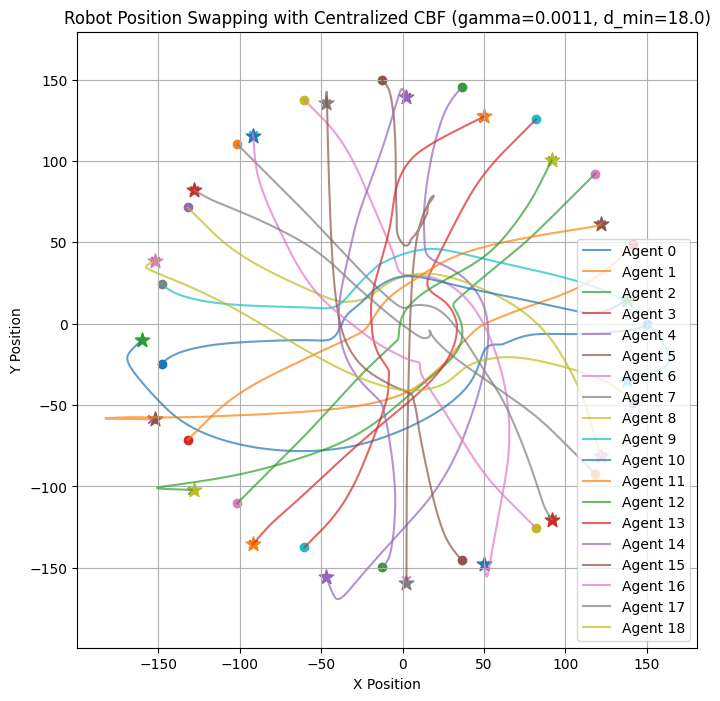

In [7]:
# --- Simulation Loop ---
for t in range(steps):
    # 1) Nominal PD control
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u_i = -k1 * (pos - ag.target) - k2 * vel
        u_i = np.clip(u_i, -ag.alpha, ag.alpha)  # keep nominal input reasonable
        u_nom_all.append(u_i)

    u_nom_all = np.array(u_nom_all, dtype=float)

    # 2) Safe control through CBF-QP
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # 3) Update agents
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        u_nom_hist[i].append(u_nom_all[i].copy())
        u_safe_hist[i].append(u_safe_all[i].copy())

# --- Convert history to arrays ---
history = [np.array(h) for h in history]
u_nom_hist = [np.array(h) for h in u_nom_hist]
u_safe_hist = [np.array(h) for h in u_safe_hist]

# --- Plot trajectories ---
plt.figure(figsize=(8, 8))
for i in range(N):
    traj = history[i]
    if len(traj) == 0:
        continue

    plt.plot(traj[:, 0], traj[:, 1], alpha=0.7, label=f'Agent {i}')
    plt.scatter(traj[0, 0], traj[0, 1], marker='o')
    plt.scatter(traj[-1, 0], traj[-1, 1], marker='x')
    plt.scatter(agents_list[i].target[0], agents_list[i].target[1], marker='*', s=120)

plt.title(f"Robot Position Swapping with Centralized CBF (gamma={gamma}, d_min={d_min})")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# --- Plot control inputs (for debugging) ---
time = np.arange(len(u_nom_hist[0])) * dt

fig, axes = plt.subplots(N, 2, figsize=(10, 3*N))

for i in range(N):
    u_nom = u_nom_hist[i]
    u_safe = u_safe_hist[i]

    # X control
    axes[i,0].plot(time, u_nom[:,0], '--', label='u_nom_x')
    axes[i,0].plot(time, u_safe[:,0], '-', label='u_safe_x')
    axes[i,0].set_title(f'Agent {i} - X acceleration')
    axes[i,0].set_xlabel('Time (s)')
    axes[i,0].set_ylabel('Acceleration')
    axes[i,0].grid(True)
    axes[i,0].legend()

    # Y control
    axes[i,1].plot(time, u_nom[:,1], '--', label='u_nom_y')
    axes[i,1].plot(time, u_safe[:,1], '-', label='u_safe_y')
    axes[i,1].set_title(f'Agent {i} - Y acceleration')
    axes[i,1].set_xlabel('Time (s)')
    axes[i,1].set_ylabel('Acceleration')
    axes[i,1].grid(True)
    axes[i,1].legend()

plt.tight_layout()
plt.show()

In [9]:
# --- Reinitialize agents ---
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N

    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    target = -np.array(x0[0:2]) - 10

    ag = Agent(i, x0, [0, 0, 0, 0], alpha=alpha_val, beta=beta_val)
    ag.target = target
    agents_list.append(ag)

# --- Animation figure ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(f"{N} Robot Swapping - Centralized CBF (gamma={gamma}, d_min={d_min})")

# plot targets
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]

# safety circles
circles = []
for ag in agents_list:
    c = plt.Circle(
        (ag.pos[0, 0], ag.pos[1, 0]),
        d_min/2,
        fill=False,
        linestyle="--",
        alpha=0.5
    )
    ax.add_patch(c)
    circles.append(c)

info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- Update function ---
def update(frame):
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u = -k1 * (pos - ag.target) - k2 * vel
        u = np.clip(u, -ag.alpha, ag.alpha)
        u_nom_all.append(u)

    u_nom_all = np.array(u_nom_all)

    # CBF filter
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # physics update
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        traj = np.array(history[i])

        x = ag.pos[0, 0]
        y = ag.pos[1, 0]

        points[i].set_data([x], [y])
        trails[i].set_data(traj[:, 0], traj[:, 1])
        circles[i].center = (x, y)

    info_text.set_text(f"Time: {frame * dt:.1f}s")

    return points + trails + circles + [info_text]

# --- Render video ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

writer = FFMpegWriter(fps=int(1 / dt), bitrate=2000)
ani.save("centralized_cbf_validation.mp4", writer=writer)

plt.close(fig)

print("Video saved: centralized_cbf_validation.mp4")

Video saved: centralized_cbf_validation.mp4


## Dynamics Topology + Centralized CBF

In [ ]:
from safety_formation.control_law.cbf import CBFTopology


CBFTopology(n=19, d_min=18.0, gamma=0.0011, alpha_min=10.0, alpha_max=10.0, beta_max=20.0)
Neighborhood radii:
 [151.7002013 151.7002013 151.7002013 151.7002013 151.7002013 151.7002013
 151.7002013 151.7002013 151.7002013 151.7002013 151.7002013 151.7002013
 151.7002013 151.7002013 151.7002013 151.7002013 151.7002013 151.7002013
 151.7002013]
Initial adjacency:
 [[0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
 [1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]
 [1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 

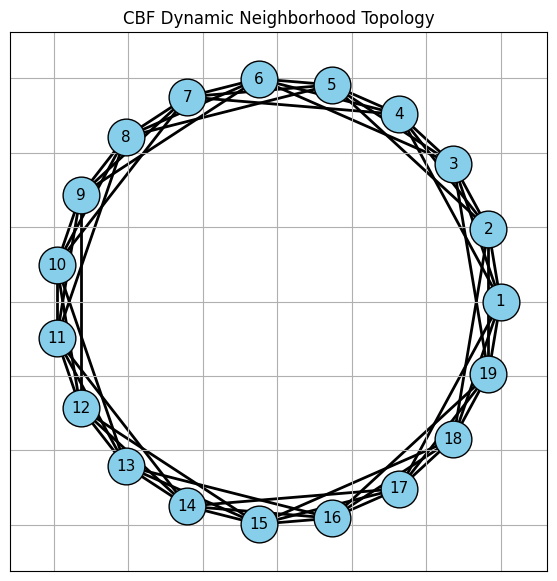

In [18]:
# --- Simulation Configuration ---
N = 19
R_circle = 150
dt = 0.1
T_max = 30.0
steps = int(T_max / dt)

gamma = 0.0011
d_min = 18.0
k1, k2 = 1.35 , 2.8

alpha_val = 10.0
beta_val = 20.0

# --- Create agents using your Agent class ---
agents_list = []

for i in range(N):
    angle = 2 * np.pi * i / N

    # Initial state: [x, y, vx, vy]
    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    # Opposite-side target
    target_pos = -np.array(x0[0:2]) - 10

    # f_target is not used in this experiment
    ag = Agent(
        agent_id=i,
        x0=x0,
        f_target=[0.0, 0.0, 0.0, 0.0],
        alpha=alpha_val,
        beta=beta_val
    )

    # attach target for this experiment
    ag.target = target_pos.reshape(2,)
    agents_list.append(ag)

# --- Fully connected topology ---
# --- CBF-induced dynamic topology ---
topology = CBFTopology(
    agent_list=agents_list,
    d_min=d_min,
    gamma=gamma
)

print(topology)
print("Neighborhood radii:\n", topology.neighborhood_radii)
print("Initial adjacency:\n", topology.adj_matrix)

# plot using actual agent positions
topology.plot(show_radius=False)

# --- CBF filter ---
cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)


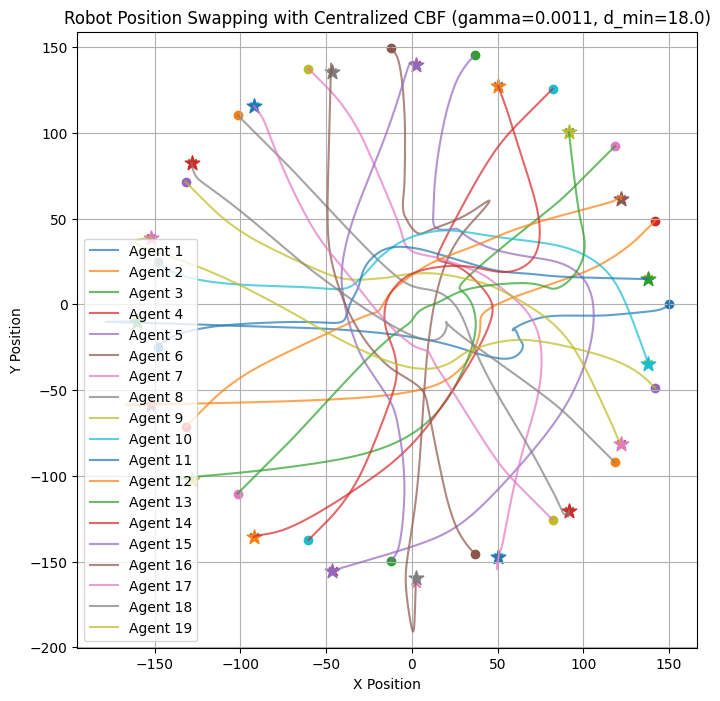

In [16]:
# --- History ---
history = [[] for _ in range(N)]
u_nom_hist = [[] for _ in range(N)]
u_safe_hist = [[] for _ in range(N)]

# --- Simulation Loop ---
for t in range(steps):
    
    topology.update_topology()
    
    # 1) Nominal PD control
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u_i = -k1 * (pos - ag.target) - k2 * vel
        u_i = np.clip(u_i, -ag.alpha, ag.alpha)  # keep nominal input reasonable
        u_nom_all.append(u_i)

    u_nom_all = np.array(u_nom_all, dtype=float)

    # 2) Safe control through CBF-QP
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # 3) Update agents
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        u_nom_hist[i].append(u_nom_all[i].copy())
        u_safe_hist[i].append(u_safe_all[i].copy())

# --- Convert history to arrays ---
history = [np.array(h) for h in history]
u_nom_hist = [np.array(h) for h in u_nom_hist]
u_safe_hist = [np.array(h) for h in u_safe_hist]

# --- Plot trajectories ---
plt.figure(figsize=(8, 8))
for i in range(N):
    traj = history[i]
    if len(traj) == 0:
        continue

    plt.plot(traj[:, 0], traj[:, 1], alpha=0.7, label=f'Agent {i+1}')
    plt.scatter(traj[0, 0], traj[0, 1], marker='o')
    plt.scatter(traj[-1, 0], traj[-1, 1], marker='x')
    plt.scatter(agents_list[i].target[0], agents_list[i].target[1], marker='*', s=120)

plt.title(f"Robot Position Swapping with Centralized CBF (gamma={gamma}, d_min={d_min})")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
# --- Reinitialize agents ---
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N

    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    target = -np.array(x0[0:2]) - 10

    ag = Agent(i, x0, [0, 0, 0, 0], alpha=alpha_val, beta=beta_val)
    ag.target = target
    agents_list.append(ag)

topology = CBFTopology(
    agent_list=agents_list,
    d_min=d_min,
    gamma=gamma
)

# --- Animation figure ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(f"{N} Robot Swapping - Centralized CBF (gamma={gamma}, d_min={d_min})")

# plot targets
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]

# safety circles
circles = []
for ag in agents_list:
    c = plt.Circle(
        (ag.pos[0, 0], ag.pos[1, 0]),
        d_min/2,
        fill=False,
        linestyle="--",
        alpha=0.5
    )
    ax.add_patch(c)
    circles.append(c)

info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- Update function ---
def update(frame):
    
    topology.update_topology()
    
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u = -k1 * (pos - ag.target) - k2 * vel
        u = np.clip(u, -ag.alpha, ag.alpha)
        u_nom_all.append(u)

    u_nom_all = np.array(u_nom_all)

    # CBF filter
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # physics update
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        traj = np.array(history[i])

        x = ag.pos[0, 0]
        y = ag.pos[1, 0]

        points[i].set_data([x], [y])
        trails[i].set_data(traj[:, 0], traj[:, 1])
        circles[i].center = (x, y)

    info_text.set_text(f"Time: {frame * dt:.1f}s")

    return points + trails + circles + [info_text]

# --- Render video ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

writer = FFMpegWriter(fps=int(1 / dt), bitrate=2000)
ani.save("centralized_cbf_validation1.mp4", writer=writer)

plt.close(fig)

print("Video saved: centralized_cbf_validation1.mp4")

Video saved: centralized_cbf_validation1.mp4
